# Stroke Health Prediction Using Machine Learning

## In this project, we analyze a healthcare dataset that contains various attributes such as age, gender, hypertension, heart disease, glucose level, BMI, smoking status, and other lifestyle factors. The goal is to understand how these factors contribute to the likelihood of a stroke and to build a machine learning model that can predict whether a person is at risk.

## Objective
### To perform Exploratory Data Analysis (EDA) and understand the dataset
### To identify key factors that influence stroke occurrence
### To handle class imbalance using techniques like SMOTE
### To build and evaluate machine learning models for stroke prediction
### To interpret the results and provide meaningful insights

In [98]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv


## Importing Libraries

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report , accuracy_score

In [100]:
df = pd.read_csv(r'/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')

In [52]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [54]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [55]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

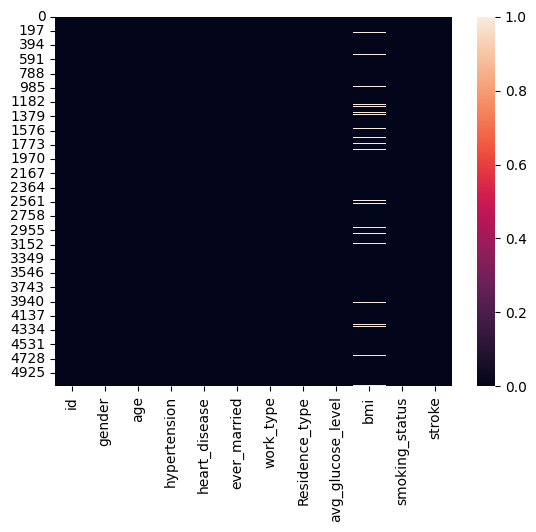

In [56]:
sns.heatmap(df.isnull())
plt.show()

## Fill the missing values of bmi using median

In [101]:

df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [102]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

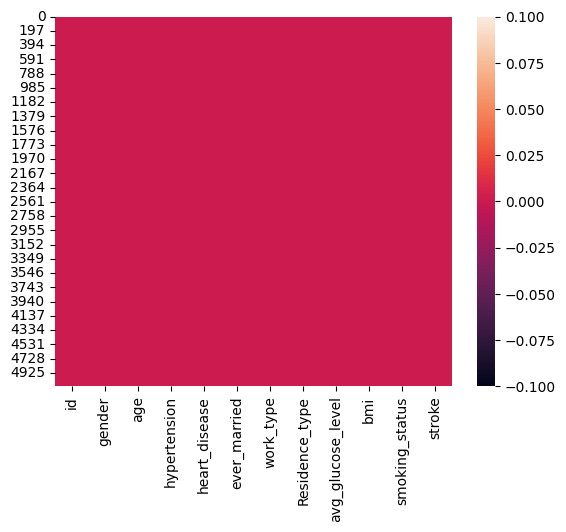

In [59]:
sns.heatmap(df.isnull())
plt.show()

## Remove Id column

In [103]:
df = df.drop(columns='id')

In [104]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

## Replace 'Others' with most frequent values

In [105]:
df['gender'] = df['gender'].replace('Other','Male')

In [106]:
df['gender'].value_counts()

gender
Female    2994
Male      2116
Name: count, dtype: int64

In [107]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Exploratory Data Analysis

### Age Vs Stroke

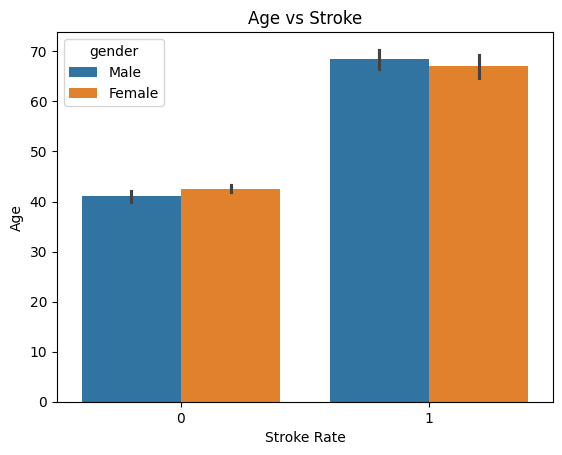

In [108]:
sns.barplot(x='stroke' , y ='age' , hue='gender',  data=df)
plt.title('Age vs Stroke')
plt.xlabel('Stroke Rate')
plt.ylabel('Age')
plt.show()

### Glucose Level Distribution 

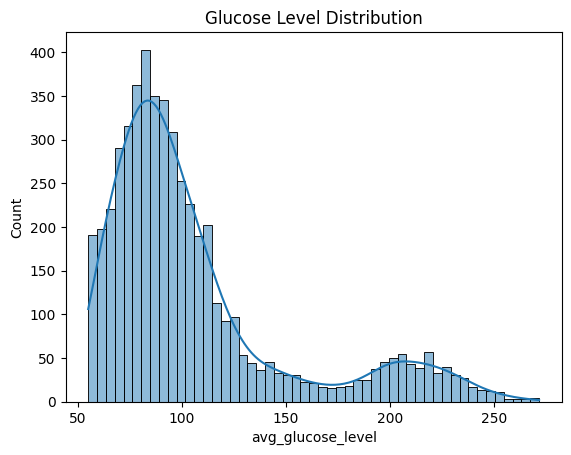

In [109]:
sns.histplot(df['avg_glucose_level'],kde=True)
plt.title('Glucose Level Distribution')
plt.show()

### BMI Level Distribution

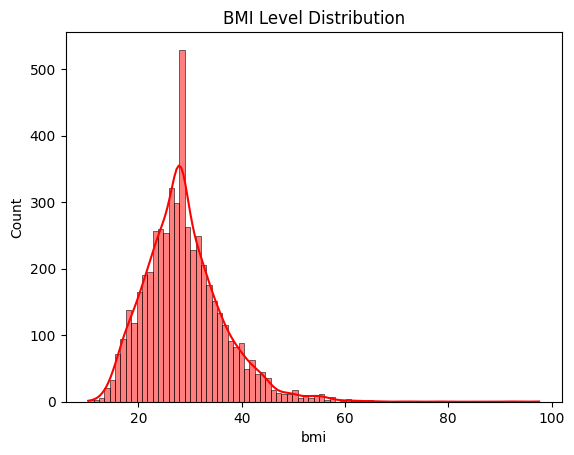

In [110]:
sns.histplot(df['bmi'],kde=True,color='red')
plt.title('BMI Level Distribution')
plt.show()

### Work Type Vs Stroke

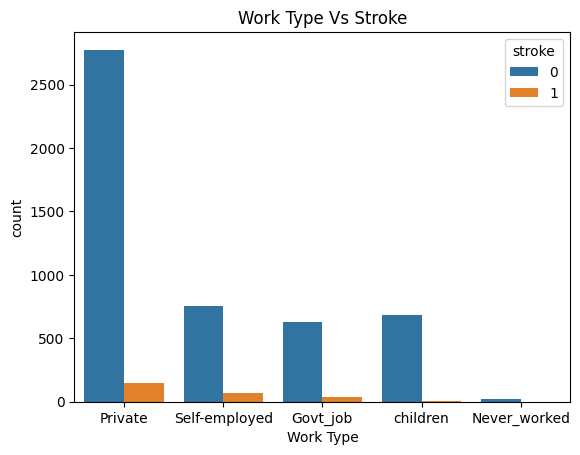

In [111]:
sns.countplot(x='work_type',hue='stroke',data=df)
plt.xlabel('Work Type')
plt.title('Work Type Vs Stroke')
plt.show()

### Residence Area Vs Stroke Probability

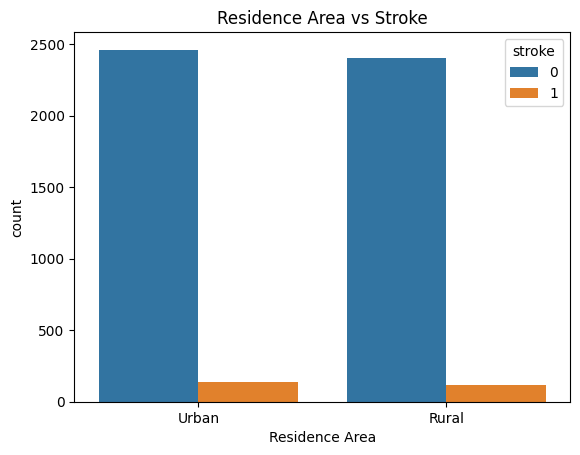

In [112]:
sns.countplot(x='Residence_type',hue='stroke',data=df)
plt.xlabel('Residence Area')
plt.title('Residence Area vs Stroke')
plt.show()

### Smoking Status Vs Stroke

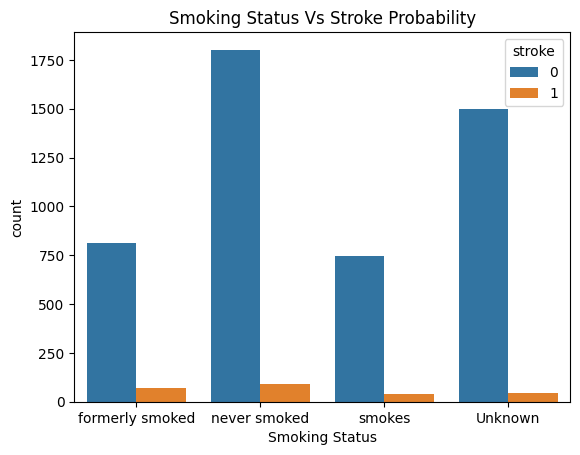

In [113]:
sns.countplot(x='smoking_status',hue='stroke',data=df)
plt.xlabel('Smoking Status')
plt.title('Smoking Status Vs Stroke Probability')
plt.show()

### Heart Disease vs Stroke Prediction

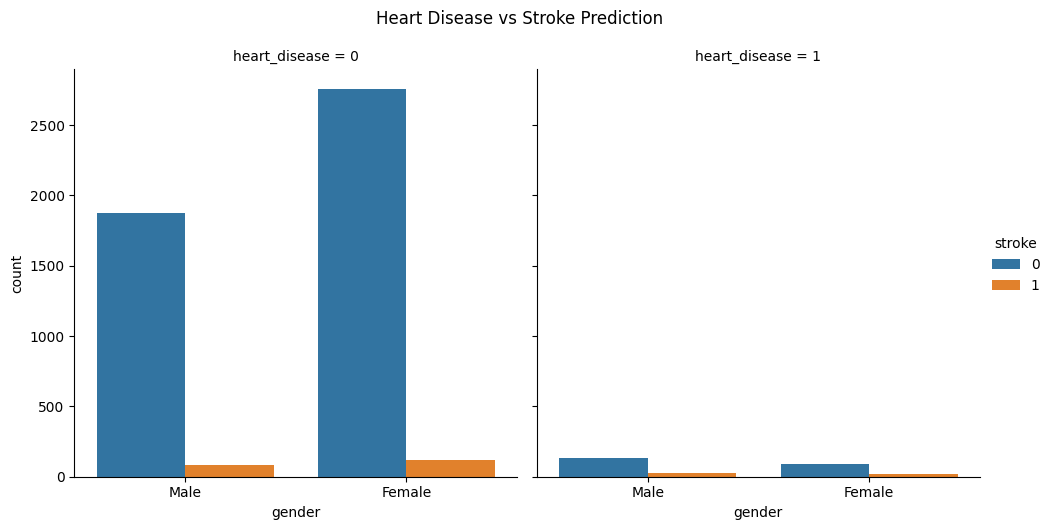

In [114]:
g = sns.catplot(x='gender',hue='stroke',col='heart_disease',kind='count',data=df)
g.fig.suptitle('Heart Disease vs Stroke Prediction',y=1.05)
plt.show()

### Hypertension Vs Stroke

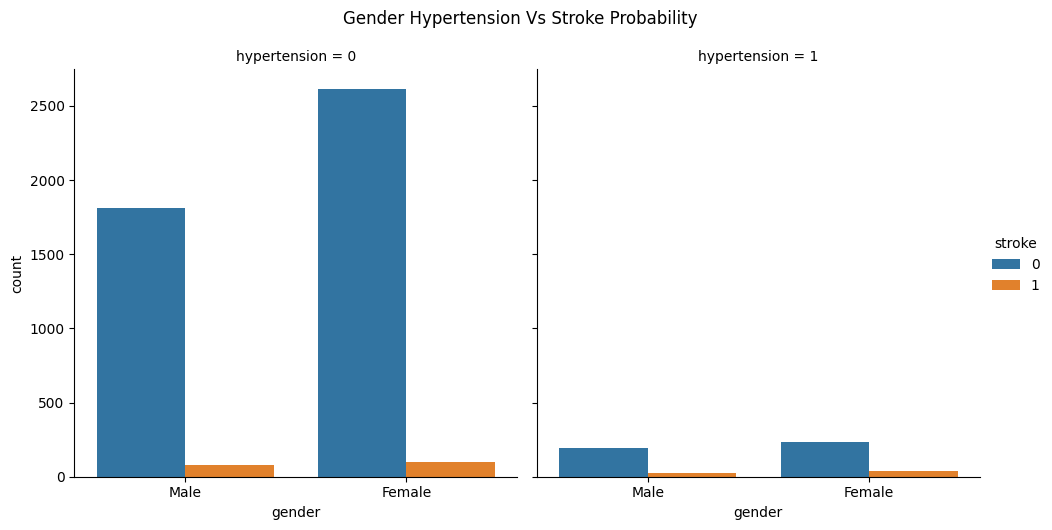

In [115]:
fig=sns.catplot(x='gender',hue='stroke',col='hypertension',data=df,kind='count')
fig.fig.suptitle('Gender Hypertension Vs Stroke Probability',y=1.05)
plt.show()

### Corealtion Map

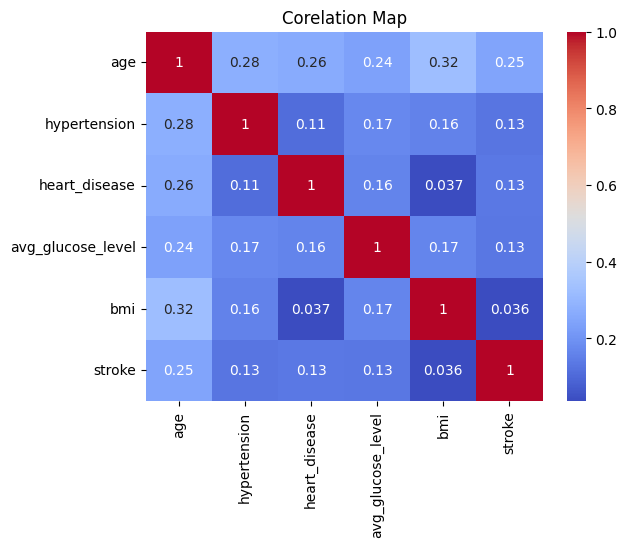

In [116]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Corelation Map')
plt.show()

## Feature Engineering Using Map

In [117]:
df['gender'] = df['gender'].map({'Male':1 , 'Female':0 })

In [118]:
df['ever_married'] = df['ever_married'].map({'Yes':1 , 'No':0})

In [119]:
df['Residence_type'] = df['Residence_type'].map({'Rural':0 ,'Urban':1})

## Feature Engineering Using One Hot Encoding

In [120]:
df = pd.get_dummies(df,columns=['work_type','smoking_status'],drop_first=True,dtype=int)

In [75]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.0,67.0,0,1,1,1,228.69,36.6,1,0,1,0,0,1,0,0
1,0.0,61.0,0,0,1,0,202.21,28.1,1,0,0,1,0,0,1,0
2,1.0,80.0,0,1,1,0,105.92,32.5,1,0,1,0,0,0,1,0
3,0.0,49.0,0,0,1,1,171.23,34.4,1,0,1,0,0,0,0,1
4,0.0,79.0,1,0,1,0,174.12,24.0,1,0,0,1,0,0,1,0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          5109 non-null   float64
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   int64  
 3   heart_disease                   5110 non-null   int64  
 4   ever_married                    5110 non-null   int64  
 5   Residence_type                  5110 non-null   int64  
 6   avg_glucose_level               5110 non-null   float64
 7   bmi                             5110 non-null   float64
 8   stroke                          5110 non-null   int64  
 9   work_type_Never_worked          5110 non-null   int64  
 10  work_type_Private               5110 non-null   int64  
 11  work_type_Self-employed         5110 non-null   int64  
 12  work_type_children              51

## Data Splitting

In [121]:
x = df.drop(columns='stroke')
y = df['stroke']

In [122]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Using SMOTE To Balanced Prediction Probability


In [123]:
sm = SMOTE()

In [124]:
x_train_rs , y_train_rs = sm.fit_resample(x_train,y_train)

In [125]:
print(y_train.value_counts())
print(y_train_rs.value_counts())

stroke
0    3901
1     187
Name: count, dtype: int64
stroke
0    3901
1    3901
Name: count, dtype: int64


## Using ML Algorithms to train the Model

In [126]:
lr = LogisticRegression(max_iter=1000)
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
dtc = DecisionTreeClassifier(random_state=42)
xgc = XGBClassifier(eval_metric='logloss')

In [127]:
lr.fit(x_train_rs,y_train_rs)


LogisticRegression(max_iter=1000)

In [128]:
rfc.fit(x_train_rs,y_train_rs)

RandomForestClassifier(n_estimators=200, random_state=42)

In [129]:
dtc.fit(x_train_rs,y_train_rs)

DecisionTreeClassifier(random_state=42)

In [130]:
xgc.fit(x_train_rs,y_train_rs)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
x_test.isnull().sum()

gender                            0
age                               0
hypertension                      0
heart_disease                     0
ever_married                      0
Residence_type                    0
avg_glucose_level                 0
bmi                               0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [133]:
y_pred_lr = lr.predict(x_test)
accu_lr = accuracy_score(y_test,y_pred_lr)

y_pred_rfc = rfc.predict(x_test)
accu_rfc = accuracy_score(y_test,y_pred_rfc)

y_pred_dtc = dtc.predict(x_test)
accu_dtc = accuracy_score(y_test,y_pred_dtc)

y_pred_xgc = xgc.predict(x_test)
accu_xgc = accuracy_score(y_test,y_pred_xgc)


In [134]:
print("-"*50)
print("Accuracy Of Logistic Regression",accu_lr * 100)
print(classification_report(y_pred_lr , y_test))

print("-"*50)
print("Accuracy Of Random Forest Classifier",accu_rfc * 100)
print(classification_report(y_pred_rfc , y_test))

print("-"*50)
print("Accuracy Of Decision Tree Classifier",accu_dtc * 100)
print(classification_report(y_pred_dtc , y_test))

print("-"*50)
print("Accuracy Of XGBClassifier",accu_xgc * 100)
print(classification_report(y_pred_xgc , y_test))

--------------------------------------------------
Accuracy Of Logistic Regression 84.54011741682974
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       884
           1       0.34      0.15      0.21       138

    accuracy                           0.85      1022
   macro avg       0.61      0.55      0.56      1022
weighted avg       0.81      0.85      0.82      1022

--------------------------------------------------
Accuracy Of Random Forest Classifier 90.8023483365949
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       974
           1       0.13      0.17      0.15        48

    accuracy                           0.91      1022
   macro avg       0.54      0.56      0.55      1022
weighted avg       0.92      0.91      0.91      1022

--------------------------------------------------
Accuracy Of Decision Tree Classifier 88.16046966731899
              precision    recall 

## In This Training Random Forest and XGBClassifier gives highest accuracy of 90.7%

In [135]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [136]:
sample = x_test.iloc[[10]]

In [139]:
for name, model in models.items():
    model.fit(x_train_rs, y_train_rs)
    
    pred = model.predict(sample)[0]
    prob = model.predict_proba(sample)[0][1]
    
    print(f"{name} → Stroke: {pred}, Probability: {prob:.2f}")

Logistic Regression → Stroke: 0, Probability: 0.12
Decision Tree → Stroke: 0, Probability: 0.00
Random Forest → Stroke: 0, Probability: 0.03
XGBoost → Stroke: 0, Probability: 0.00


# Final Outcome
## Successfully built a predictive system for stroke risk
## Handled data imbalance and missing values effectively
## Compared multiple models and selected the best one
## Generated interpretable predictions with probabilities

# Future Improvements
## Use more real-world data for better generalization
## Apply hyperparameter tuning for improved accuracy
## Deploy the model using a web app (e.g., Streamlit)
## Incorporate additional medical features for higher reliability